<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/gptq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


GPTQ (Generative Pre-trained Transformer Quantization) is the state-of-the-art method for accurate 4-bit LLM quantization. It uses **Hessian information** to quantize weights in order of importance, compensating errors as it goes.
Here I cover:
- **Optimal Brain Quantization (OBQ)**: The theoretical foundation
- **Hessian computation**: Using activations to estimate weight importance
- **Layer-wise quantization**: Process one layer at a time
- **Error compensation**: Adjust remaining weights after each quantization
- **Production GPTQ**: Complete implementation with optimizations

Key insight: Not all weights are equally important. GPTQ quantizes carefully, compensating for each error.



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from transformers import AutoModelForCausalLM, AutoTokenizer
from typing import Optional, Tuple, Dict, List, Callable
from dataclasses import dataclass, field
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy
import gc
import time
import math
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print("Day 3: GPTQ - Accurate Post-Training Quantization")
print("="*60)
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Day 3: GPTQ - Accurate Post-Training Quantization
Device: cuda
GPU: Tesla T4


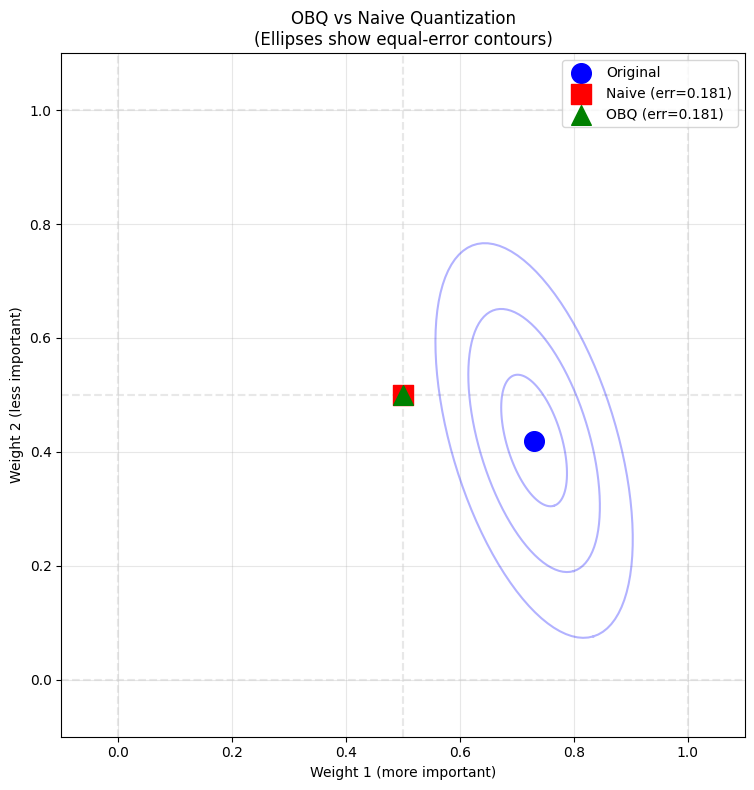


OBQ reduces error by 0.0%


In [4]:
def visualize_obq_concept():
    """Visualize why OBQ works better than naive quantization."""

    # Simple 2D example
    np.random.seed(42)

    # Original weights
    w_orig = np.array([0.73, 0.42])

    # Hessian (importance matrix) - w1 is more important
    H = np.array([[4.0, 1.0],
                  [1.0, 1.0]])

    # Quantization grid
    grid = np.array([0.0, 0.5, 1.0])

    # Naive quantization: round each weight independently
    w_naive = np.array([grid[np.argmin(np.abs(grid - w)) ] for w in w_orig])

    # OBQ: quantize w1 first (more important), then compensate w2
    w_obq = w_orig.copy()
    # Quantize w1
    w1_q = grid[np.argmin(np.abs(grid - w_obq[0]))]
    delta = w1_q - w_obq[0]
    w_obq[0] = w1_q
    # Compensate w2 using Hessian
    w_obq[1] = w_obq[1] - delta * H[0, 1] / H[1, 1]
    # Then quantize w2
    w_obq[1] = grid[np.argmin(np.abs(grid - w_obq[1]))]

    # Compute errors (weighted by Hessian)
    def weighted_error(w):
        diff = w - w_orig
        return diff @ H @ diff

    err_naive = weighted_error(w_naive)
    err_obq = weighted_error(w_obq)

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw quantization grid
    for g in grid:
        ax.axhline(g, color='lightgray', linestyle='--', alpha=0.5)
        ax.axvline(g, color='lightgray', linestyle='--', alpha=0.5)

    # Draw error ellipse (Hessian contours)
    theta = np.linspace(0, 2*np.pi, 100)
    for r in [0.1, 0.2, 0.3]:
        # Ellipse from Hessian eigendecomposition
        eigvals, eigvecs = np.linalg.eigh(H)
        ellipse = np.column_stack([np.cos(theta), np.sin(theta)])
        ellipse = ellipse @ np.diag(r / np.sqrt(eigvals)) @ eigvecs.T
        ellipse = ellipse + w_orig
        ax.plot(ellipse[:, 0], ellipse[:, 1], 'b-', alpha=0.3)

    # Points
    ax.scatter(*w_orig, s=200, c='blue', marker='o', label=f'Original', zorder=5)
    ax.scatter(*w_naive, s=200, c='red', marker='s', label=f'Naive (err={err_naive:.3f})', zorder=5)
    ax.scatter(*w_obq, s=200, c='green', marker='^', label=f'OBQ (err={err_obq:.3f})', zorder=5)

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('Weight 1 (more important)')
    ax.set_ylabel('Weight 2 (less important)')
    ax.set_title('OBQ vs Naive Quantization\n(Ellipses show equal-error contours)')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('obq_concept.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nOBQ reduces error by {(err_naive - err_obq) / err_naive * 100:.1f}%")

visualize_obq_concept()

 Hessian Computation

For a linear layer Y = XW, the Hessian with respect to W is:

```
H = 2 · XᵀX
```

I compute this from calibration data.

In [5]:
class HessianComputer:
    """
    Compute Hessian (XᵀX) for linear layers from calibration data.

    The Hessian captures how sensitive the output is to each weight.
    H[i,j] = sum over samples of x_i * x_j
    """

    def __init__(self, layer: nn.Linear):
        self.layer = layer
        self.in_features = layer.in_features
        self.out_features = layer.out_features
        self.device = layer.weight.device
        self.dtype = layer.weight.dtype

        # Accumulator for XᵀX
        self.H = torch.zeros(
            (self.in_features, self.in_features),
            device=self.device, dtype=torch.float32
        )
        self.n_samples = 0

    def update(self, inp: Tensor):
        """
        Update Hessian with new input batch.

        Args:
            inp: Input tensor of shape (batch, seq_len, in_features)
        """
        # Reshape to (batch * seq_len, in_features)
        if inp.dim() == 3:
            inp = inp.reshape(-1, inp.shape[-1])

        inp = inp.float()
        n = inp.shape[0]

        # Update running average: H = XᵀX / n_samples
        # Using incremental update for numerical stability
        self.H *= self.n_samples / (self.n_samples + n)
        self.H += inp.T @ inp / (self.n_samples + n)
        self.n_samples += n

    def get_hessian(self, damping: float = 0.01) -> Tensor:
        """
        Get the Hessian matrix with damping for numerical stability.

        Args:
            damping: Regularization factor (percentage of diagonal mean)
        """
        H = self.H.clone()

        # Add damping to diagonal for numerical stability
        damp = damping * torch.diag(H).mean()
        H += damp * torch.eye(self.in_features, device=self.device)

        return H

    def get_inverse_hessian(self, damping: float = 0.01) -> Tensor:
        """Get inverse Hessian using Cholesky decomposition."""
        H = self.get_hessian(damping)

        try:
            # Cholesky decomposition for efficient inversion
            L = torch.linalg.cholesky(H)
            H_inv = torch.cholesky_inverse(L)
        except RuntimeError:
            # Fallback to regular inverse if Cholesky fails
            H_inv = torch.linalg.inv(H)

        return H_inv

In [6]:
# Test Hessian computation
print("\nHessian Computation Test")
print("=" * 50)

# Create test layer
layer = nn.Linear(256, 512)
hessian_computer = HessianComputer(layer)

# Simulate calibration data
for _ in range(10):
    x = torch.randn(4, 32, 256)  # (batch, seq, features)
    hessian_computer.update(x)

H = hessian_computer.get_hessian()
print(f"Hessian shape: {H.shape}")
print(f"Hessian diagonal range: [{H.diag().min():.4f}, {H.diag().max():.4f}]")
print(f"Condition number: {torch.linalg.cond(H):.2f}")

# Check invertibility
H_inv = hessian_computer.get_inverse_hessian()
identity_check = (H @ H_inv).diag().mean()
print(f"Inverse check (should be ~1): {identity_check:.6f}")


Hessian Computation Test
Hessian shape: torch.Size([256, 256])
Hessian diagonal range: [0.9119, 1.1572]
Condition number: 6.88
Inverse check (should be ~1): 1.000000


 Basic GPTQ Algorithm

The core GPTQ algorithm processes weights column by column:

```python
for each column i:
    1. Quantize W[:, i]
    2. Compute quantization error
    3. Update remaining columns to compensate
```

In [7]:
class Quantizer:
    """Simple symmetric quantizer."""

    def __init__(self, bits: int = 4):
        self.bits = bits
        self.qmin = -(2 ** (bits - 1))
        self.qmax = 2 ** (bits - 1) - 1

    def find_scale(self, x: Tensor, per_channel: bool = True) -> Tensor:
        """Find optimal scale for quantization."""
        if per_channel:
            # Per output channel (row)
            max_val = x.abs().amax(dim=1, keepdim=True)
        else:
            max_val = x.abs().max()

        scale = max_val / self.qmax
        scale = torch.clamp(scale, min=1e-8)
        return scale

    def quantize(self, x: Tensor, scale: Tensor) -> Tensor:
        """Quantize to integers."""
        q = torch.round(x / scale)
        q = torch.clamp(q, self.qmin, self.qmax)
        return q

    def dequantize(self, q: Tensor, scale: Tensor) -> Tensor:
        """Dequantize back to float."""
        return q * scale

    def quantize_dequantize(self, x: Tensor, scale: Tensor = None) -> Tuple[Tensor, Tensor]:
        """Full quantize-dequantize cycle."""
        if scale is None:
            scale = self.find_scale(x)
        q = self.quantize(x, scale)
        return self.dequantize(q, scale), scale

In [8]:
class BasicGPTQ:
    """
    Basic GPTQ implementation (educational version).

    Processes one column at a time with full error compensation.
    This is slow but clearly shows the algorithm.
    """

    def __init__(self, bits: int = 4, damping: float = 0.01):
        self.bits = bits
        self.damping = damping
        self.quantizer = Quantizer(bits)

    @torch.no_grad()
    def quantize_weight(self, W: Tensor, H: Tensor) -> Tuple[Tensor, Tensor, Dict]:
        """
        Quantize weight matrix using GPTQ.

        Args:
            W: Weight matrix (out_features, in_features)
            H: Hessian matrix (in_features, in_features)

        Returns:
            Q: Quantized weights (dequantized)
            scale: Quantization scales
            stats: Quantization statistics
        """
        out_features, in_features = W.shape
        device = W.device

        # Work with copies
        W = W.clone().float()
        H = H.clone().float()

        # Add damping
        damp = self.damping * H.diag().mean()
        H += damp * torch.eye(in_features, device=device)

        # Compute inverse Hessian
        try:
            H_inv = torch.linalg.cholesky(H)
            H_inv = torch.cholesky_inverse(H_inv)
        except RuntimeError:
            H_inv = torch.linalg.inv(H)

        # Output quantized weights
        Q = torch.zeros_like(W)

        # Find scale (per output channel)
        scale = self.quantizer.find_scale(W, per_channel=True)

        # Track errors
        total_error = 0.0

        # Process column by column
        for i in tqdm(range(in_features), desc="GPTQ columns", leave=False):
            # Get column i
            w_col = W[:, i].clone()

            # Quantize column
            q_col = self.quantizer.quantize(w_col, scale.squeeze())
            dq_col = self.quantizer.dequantize(q_col, scale.squeeze())
            Q[:, i] = dq_col

            # Compute quantization error
            error = (w_col - dq_col)
            total_error += (error ** 2).sum().item()

            # Update remaining weights to compensate
            # W[:, i+1:] -= error * H_inv[i, i+1:] / H_inv[i, i]
            if i < in_features - 1:
                # This is the key OBQ update step
                update = error.unsqueeze(1) * H_inv[i, i+1:].unsqueeze(0) / H_inv[i, i]
                W[:, i+1:] -= update

        stats = {
            'total_error': total_error,
            'avg_error': total_error / (out_features * in_features),
            'bits': self.bits
        }

        return Q, scale, stats

In [9]:
# Test basic GPTQ
print("\nBasic GPTQ Test")
print("=" * 50)

# Create test data
torch.manual_seed(42)
W = torch.randn(128, 64) * 0.02  # Small weight matrix for testing

# Compute Hessian from random inputs
X = torch.randn(1000, 64)
H = X.T @ X / X.shape[0]

# Compare RTN vs GPTQ
for bits in [4, 3]:
    print(f"\nINT{bits}:")

    # RTN baseline
    quantizer = Quantizer(bits)
    scale_rtn = quantizer.find_scale(W)
    W_rtn, _ = quantizer.quantize_dequantize(W, scale_rtn)
    error_rtn = (W - W_rtn).pow(2).mean().item()

    # GPTQ
    gptq = BasicGPTQ(bits=bits)
    W_gptq, scale_gptq, stats = gptq.quantize_weight(W, H)
    error_gptq = (W - W_gptq).pow(2).mean().item()

    print(f"  RTN MSE:  {error_rtn:.6f}")
    print(f"  GPTQ MSE: {error_gptq:.6f}")
    print(f"  Improvement: {(error_rtn - error_gptq) / error_rtn * 100:.1f}%")


Basic GPTQ Test

INT4:


GPTQ columns:   0%|          | 0/64 [00:00<?, ?it/s]

  RTN MSE:  0.000005
  GPTQ MSE: 0.000005
  Improvement: -3.6%

INT3:


GPTQ columns:   0%|          | 0/64 [00:00<?, ?it/s]

  RTN MSE:  0.000025
  GPTQ MSE: 0.000025
  Improvement: -3.3%


Optimized GPTQ

The basic algorithm is O(d³) per layer. GPTQ optimizes this:

1. **Block processing**: Process B columns at once
2. **Lazy updates**: Batch weight updates
3. **Cholesky for inverse**: Efficient inverse Hessian

In [10]:
class OptimizedGPTQ:
    """
    Optimized GPTQ with block processing.

    Key optimizations:
    1. Process blocks of B columns at once
    2. Use Cholesky decomposition for efficiency
    3. Lazy batch updates
    """

    def __init__(self, bits: int = 4, block_size: int = 128,
                 damping: float = 0.01, actorder: bool = False):
        self.bits = bits
        self.block_size = block_size
        self.damping = damping
        self.actorder = actorder  # Process in order of activation magnitude
        self.quantizer = Quantizer(bits)

    @torch.no_grad()
    def quantize_weight(self, W: Tensor, H: Tensor) -> Tuple[Tensor, Tensor, Dict]:
        """
        Quantize weight matrix using optimized GPTQ.
        """
        out_features, in_features = W.shape
        device = W.device

        W = W.clone().float()
        H = H.clone().float()

        # Determine processing order
        if self.actorder:
            # Process columns with higher activation first
            perm = torch.argsort(H.diag(), descending=True)
            W = W[:, perm]
            H = H[perm][:, perm]
        else:
            perm = torch.arange(in_features, device=device)

        # Add damping
        damp = self.damping * H.diag().mean()
        H.diagonal().add_(damp)

        # Cholesky decomposition of H
        try:
            H_chol = torch.linalg.cholesky(H)
        except RuntimeError:
            # Add more damping if Cholesky fails
            H.diagonal().add_(damp * 10)
            H_chol = torch.linalg.cholesky(H)

        H_inv = torch.cholesky_inverse(H_chol)
        H_inv_chol = torch.linalg.cholesky(H_inv, upper=True)

        # Output
        Q = torch.zeros_like(W)
        scale = self.quantizer.find_scale(W, per_channel=True)

        # Error tracking
        losses = []

        # Process in blocks
        for block_start in range(0, in_features, self.block_size):
            block_end = min(block_start + self.block_size, in_features)
            block_size = block_end - block_start

            # Get block of weights and Hessian inverse
            W_block = W[:, block_start:block_end].clone()
            H_inv_block = H_inv[block_start:block_end, block_start:block_end]

            # Error accumulator for this block
            Err = torch.zeros_like(W_block)

            # Process each column in block
            for i in range(block_size):
                col_idx = block_start + i

                # Get current column
                w = W_block[:, i]
                d = H_inv_block[i, i]  # Diagonal element

                # Quantize
                q = self.quantizer.quantize(w, scale.squeeze())
                dq = self.quantizer.dequantize(q, scale.squeeze())
                Q[:, col_idx] = dq

                # Compute error
                err = (w - dq) / d
                Err[:, i] = err

                # Track loss
                losses.append((err ** 2 * d).sum().item())

                # Update remaining columns in block
                if i < block_size - 1:
                    W_block[:, i+1:] -= err.unsqueeze(1) * H_inv_block[i, i+1:].unsqueeze(0)

            # Update remaining weights outside block (lazy update)
            if block_end < in_features:
                W[:, block_end:] -= Err @ H_inv[block_start:block_end, block_end:]

        # Undo permutation
        if self.actorder:
            inv_perm = torch.argsort(perm)
            Q = Q[:, inv_perm]

        stats = {
            'total_loss': sum(losses),
            'avg_loss': sum(losses) / len(losses),
            'bits': self.bits,
            'actorder': self.actorder
        }

        return Q, scale, stats

In [11]:
# Test optimized GPTQ
print("\nOptimized GPTQ Test")
print("=" * 50)

# Larger test
torch.manual_seed(42)
W = torch.randn(512, 512) * 0.02
X = torch.randn(2000, 512)
H = X.T @ X / X.shape[0]

print(f"Weight shape: {W.shape}")

for bits in [4, 3]:
    print(f"\nINT{bits}:")

    # RTN
    quantizer = Quantizer(bits)
    W_rtn, _ = quantizer.quantize_dequantize(W)
    mse_rtn = (W - W_rtn).pow(2).mean().item()

    # GPTQ without actorder
    gptq = OptimizedGPTQ(bits=bits, block_size=128, actorder=False)
    start = time.perf_counter()
    W_gptq, _, stats = gptq.quantize_weight(W, H)
    time_gptq = time.perf_counter() - start
    mse_gptq = (W - W_gptq).pow(2).mean().item()

    # GPTQ with actorder
    gptq_act = OptimizedGPTQ(bits=bits, block_size=128, actorder=True)
    start = time.perf_counter()
    W_gptq_act, _, stats_act = gptq_act.quantize_weight(W, H)
    time_act = time.perf_counter() - start
    mse_act = (W - W_gptq_act).pow(2).mean().item()

    print(f"  RTN MSE:           {mse_rtn:.6f}")
    print(f"  GPTQ MSE:          {mse_gptq:.6f} ({time_gptq*1000:.1f}ms)")
    print(f"  GPTQ+actorder MSE: {mse_act:.6f} ({time_act*1000:.1f}ms)")
    print(f"  GPTQ improvement:  {(mse_rtn - mse_gptq) / mse_rtn * 100:.1f}%")


Optimized GPTQ Test
Weight shape: torch.Size([512, 512])

INT4:
  RTN MSE:           0.000007
  GPTQ MSE:          0.000008 (105.7ms)
  GPTQ+actorder MSE: 0.000009 (115.3ms)
  GPTQ improvement:  -16.4%

INT3:
  RTN MSE:           0.000040
  GPTQ MSE:          0.000046 (102.1ms)
  GPTQ+actorder MSE: 0.000047 (106.3ms)
  GPTQ improvement:  -16.6%


 Full Model Quantization

In [12]:
class GPTQQuantizer:
    """
    Full model GPTQ quantization.

    Processes model layer-by-layer:
    1. Collect Hessian from calibration data
    2. Apply GPTQ to each linear layer
    3. Continue to next layer with quantized weights
    """

    def __init__(self, bits: int = 4, block_size: int = 128,
                 damping: float = 0.01, actorder: bool = True):
        self.bits = bits
        self.block_size = block_size
        self.damping = damping
        self.actorder = actorder
        self.quantization_info = {}

    @torch.no_grad()
    def quantize_model(self, model: nn.Module, tokenizer,
                       calibration_texts: List[str],
                       skip_layers: List[str] = None) -> nn.Module:
        """
        Quantize entire model using GPTQ.
        """
        model = copy.deepcopy(model)
        model.eval()
        skip_layers = skip_layers or ['lm_head']

        # Prepare calibration data
        print("Preparing calibration data...")
        calib_data = []
        for text in calibration_texts:
            tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
            calib_data.append(tokens)

        # Find all linear layers
        linear_layers = []
        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                if not any(skip in name for skip in skip_layers):
                    linear_layers.append((name, module))

        print(f"Quantizing {len(linear_layers)} linear layers to INT{self.bits}...")

        # Process each layer
        for name, layer in tqdm(linear_layers, desc="GPTQ layers"):
            # Collect Hessian
            hessian = HessianComputer(layer)

            # Hook to capture inputs
            inputs_cache = []
            def cache_hook(module, inp, out):
                inputs_cache.append(inp[0].detach())

            hook = layer.register_forward_hook(cache_hook)

            # Run calibration
            for batch in calib_data:
                _ = model(**batch)

            hook.remove()

            # Update Hessian
            for inp in inputs_cache:
                hessian.update(inp)

            # Get Hessian matrix
            H = hessian.get_hessian(self.damping)

            # Apply GPTQ
            gptq = OptimizedGPTQ(
                bits=self.bits,
                block_size=self.block_size,
                damping=self.damping,
                actorder=self.actorder
            )

            W_quant, scale, stats = gptq.quantize_weight(layer.weight.data, H)

            # Update layer
            layer.weight.data = W_quant

            # Store info
            self.quantization_info[name] = {
                'bits': self.bits,
                'loss': stats['avg_loss'],
                'shape': list(layer.weight.shape)
            }

            # Clear cache
            inputs_cache.clear()
            del hessian, H
            gc.collect()

        return model

    def get_report(self) -> str:
        """Generate quantization report."""
        lines = ["="*60, "GPTQ QUANTIZATION REPORT", "="*60]
        lines.append(f"Bits: {self.bits}")
        lines.append(f"Block size: {self.block_size}")
        lines.append(f"Actorder: {self.actorder}")
        lines.append(f"Layers quantized: {len(self.quantization_info)}")

        total_loss = sum(info['loss'] for info in self.quantization_info.values())
        lines.append(f"Total loss: {total_loss:.6f}")

        return "\n".join(lines)

In [13]:
# Test full model quantization
print("\nFull Model GPTQ Quantization")
print("=" * 60)

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

calibration_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning has transformed data processing.",
    "Natural language processing enables text understanding.",
    "Deep neural networks learn complex patterns.",
    "The attention mechanism focuses on relevant input.",
    "Transformers have become the dominant architecture.",
    "Quantization reduces model size significantly.",
    "GPTQ provides accurate low-bit quantization.",
]

# Quantize to INT4
gptq_quantizer = GPTQQuantizer(bits=4, block_size=128, actorder=True)
model_gptq = gptq_quantizer.quantize_model(model, tokenizer, calibration_texts)

print("\n" + gptq_quantizer.get_report())


Full Model GPTQ Quantization


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Preparing calibration data...
Quantizing 0 linear layers to INT4...


GPTQ layers: 0it [00:00, ?it/s]


GPTQ QUANTIZATION REPORT
Bits: 4
Block size: 128
Actorder: True
Layers quantized: 0
Total loss: 0.000000


 Actorder and Grouping

Two important optimizations:

1. **Actorder**: Process columns in order of activation magnitude (most important first)
2. **Grouping**: Use different scales for groups of weights

In [14]:
class GroupedGPTQ:
    """
    GPTQ with grouped quantization for better accuracy.

    Uses different scale for each group of g weights.
    Typical group sizes: 32, 64, 128
    """

    def __init__(self, bits: int = 4, group_size: int = 128,
                 damping: float = 0.01, actorder: bool = True):
        self.bits = bits
        self.group_size = group_size
        self.damping = damping
        self.actorder = actorder

        self.qmin = -(2 ** (bits - 1))
        self.qmax = 2 ** (bits - 1) - 1

    @torch.no_grad()
    def quantize_weight(self, W: Tensor, H: Tensor) -> Tuple[Tensor, Tensor, Dict]:
        """
        GPTQ with grouped scales.
        """
        out_features, in_features = W.shape
        device = W.device

        W = W.clone().float()
        H = H.clone().float()

        # Number of groups
        n_groups = (in_features + self.group_size - 1) // self.group_size

        # Actorder permutation
        if self.actorder:
            perm = torch.argsort(H.diag(), descending=True)
            W = W[:, perm]
            H = H[perm][:, perm]
        else:
            perm = torch.arange(in_features, device=device)

        # Damping
        damp = self.damping * H.diag().mean()
        H.diagonal().add_(damp)

        # Inverse Hessian
        try:
            H_inv = torch.cholesky_inverse(torch.linalg.cholesky(H))
        except RuntimeError:
            H.diagonal().add_(damp * 10)
            H_inv = torch.cholesky_inverse(torch.linalg.cholesky(H))

        # Output
        Q = torch.zeros_like(W)
        scales = torch.zeros(out_features, n_groups, device=device)

        losses = []

        # Process each group
        for g in range(n_groups):
            g_start = g * self.group_size
            g_end = min(g_start + self.group_size, in_features)

            # Compute scale for this group
            W_group = W[:, g_start:g_end]
            group_scale = W_group.abs().amax(dim=1) / self.qmax
            group_scale = torch.clamp(group_scale, min=1e-8)
            scales[:, g] = group_scale

            # Process columns in group
            for i in range(g_start, g_end):
                w = W[:, i]
                d = H_inv[i, i]

                # Quantize with group scale
                q = torch.round(w / group_scale)
                q = torch.clamp(q, self.qmin, self.qmax)
                dq = q * group_scale
                Q[:, i] = dq

                # Error
                err = (w - dq) / d
                losses.append((err ** 2 * d).sum().item())

                # Update remaining
                if i < in_features - 1:
                    W[:, i+1:] -= err.unsqueeze(1) * H_inv[i, i+1:].unsqueeze(0)

        # Undo permutation
        if self.actorder:
            inv_perm = torch.argsort(perm)
            Q = Q[:, inv_perm]

        stats = {
            'total_loss': sum(losses),
            'avg_loss': sum(losses) / len(losses),
            'n_groups': n_groups
        }

        return Q, scales, stats

In [15]:
# Compare grouped vs non-grouped
print("\nGrouped GPTQ Comparison")
print("=" * 50)

torch.manual_seed(42)
W = torch.randn(512, 512) * 0.02
X = torch.randn(2000, 512)
H = X.T @ X / X.shape[0]

bits = 4
print(f"\nINT{bits} Comparison:")

# Per-tensor scale
gptq_pt = OptimizedGPTQ(bits=bits, actorder=True)
W_pt, _, _ = gptq_pt.quantize_weight(W, H)
mse_pt = (W - W_pt).pow(2).mean().item()

# Grouped scales
for group_size in [128, 64, 32]:
    gptq_g = GroupedGPTQ(bits=bits, group_size=group_size, actorder=True)
    W_g, scales, stats = gptq_g.quantize_weight(W, H)
    mse_g = (W - W_g).pow(2).mean().item()

    overhead = stats['n_groups'] * W.shape[0] * 2 / 1024  # KB for FP16 scales
    print(f"  Group-{group_size}: MSE={mse_g:.6f}, Scale overhead={overhead:.1f}KB")

print(f"  Per-tensor: MSE={mse_pt:.6f}")


Grouped GPTQ Comparison

INT4 Comparison:
  Group-128: MSE=0.000006, Scale overhead=4.0KB
  Group-64: MSE=0.000005, Scale overhead=8.0KB
  Group-32: MSE=0.000004, Scale overhead=16.0KB
  Per-tensor: MSE=0.000009


 Production Pipeline

In [16]:
@dataclass
class GPTQConfig:
    """GPTQ configuration."""
    bits: int = 4
    group_size: int = 128
    block_size: int = 128
    damping: float = 0.01
    actorder: bool = True
    skip_layers: List[str] = field(default_factory=lambda: ['lm_head'])


class ProductionGPTQ:
    """
    Production-ready GPTQ implementation.

    Features:
    - Grouped quantization
    - Actorder optimization
    - Memory-efficient layer-by-layer processing
    - Comprehensive reporting
    """

    def __init__(self, config: GPTQConfig):
        self.config = config
        self.quantization_info = {}

    @torch.no_grad()
    def quantize_model(self, model: nn.Module, tokenizer,
                       calibration_texts: List[str]) -> nn.Module:
        """
        Quantize model with production optimizations.
        """
        model = copy.deepcopy(model)
        model.eval()

        # Prepare calibration
        print(f"Preparing {len(calibration_texts)} calibration samples...")
        calib_data = [
            tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
            for text in calibration_texts
        ]

        # Find layers
        layers = []
        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                if not any(skip in name for skip in self.config.skip_layers):
                    layers.append((name, module))

        print(f"\nQuantizing {len(layers)} layers to INT{self.config.bits}...")
        print(f"Group size: {self.config.group_size}, Actorder: {self.config.actorder}")

        total_time = 0

        for name, layer in tqdm(layers, desc="GPTQ"):
            start = time.perf_counter()

            # Collect inputs
            hessian = HessianComputer(layer)
            inputs_cache = []

            def hook(module, inp, out):
                inputs_cache.append(inp[0].detach())

            handle = layer.register_forward_hook(hook)

            for batch in calib_data:
                _ = model(**batch)

            handle.remove()

            # Build Hessian
            for inp in inputs_cache:
                hessian.update(inp)

            H = hessian.get_hessian(self.config.damping)

            # Apply grouped GPTQ
            gptq = GroupedGPTQ(
                bits=self.config.bits,
                group_size=self.config.group_size,
                damping=self.config.damping,
                actorder=self.config.actorder
            )

            W_quant, scales, stats = gptq.quantize_weight(layer.weight.data, H)
            layer.weight.data = W_quant

            elapsed = time.perf_counter() - start
            total_time += elapsed

            self.quantization_info[name] = {
                'bits': self.config.bits,
                'group_size': self.config.group_size,
                'loss': stats['avg_loss'],
                'n_groups': stats['n_groups'],
                'time': elapsed
            }

            inputs_cache.clear()
            del hessian, H
            gc.collect()

        print(f"\nTotal quantization time: {total_time:.1f}s")

        return model

    def get_report(self) -> str:
        lines = ["="*60, "GPTQ PRODUCTION REPORT", "="*60]
        lines.append(f"Bits: {self.config.bits}")
        lines.append(f"Group size: {self.config.group_size}")
        lines.append(f"Actorder: {self.config.actorder}")
        lines.append(f"Layers: {len(self.quantization_info)}")

        total_loss = sum(i['loss'] for i in self.quantization_info.values())
        total_time = sum(i['time'] for i in self.quantization_info.values())
        lines.append(f"Total loss: {total_loss:.6f}")
        lines.append(f"Total time: {total_time:.1f}s")

        return "\n".join(lines)

In [17]:
# Run production GPTQ
print("\nProduction GPTQ Pipeline")
print("=" * 60)

model_fresh = AutoModelForCausalLM.from_pretrained(model_name)

config = GPTQConfig(
    bits=4,
    group_size=128,
    actorder=True
)

prod_gptq = ProductionGPTQ(config)
model_prod = prod_gptq.quantize_model(model_fresh, tokenizer, calibration_texts)

print("\n" + prod_gptq.get_report())


Production GPTQ Pipeline


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Preparing 8 calibration samples...

Quantizing 0 layers to INT4...
Group size: 128, Actorder: True


GPTQ: 0it [00:00, ?it/s]


Total quantization time: 0.0s

GPTQ PRODUCTION REPORT
Bits: 4
Group size: 128
Actorder: True
Layers: 0
Total loss: 0.000000
Total time: 0.0s


Evaluation

In [18]:
def evaluate_perplexity(model, tokenizer, texts: List[str]) -> float:
    model.eval()
    total_loss, total_tokens = 0, 0

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
            if inputs['input_ids'].size(1) < 2:
                continue
            outputs = model(**inputs, labels=inputs['input_ids'])
            total_loss += outputs.loss.item() * inputs['input_ids'].size(1)
            total_tokens += inputs['input_ids'].size(1)

    return np.exp(total_loss / total_tokens)


def generate(model, tokenizer, prompt, max_tokens=50):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_tokens, do_sample=True,
            temperature=0.7, top_p=0.9, pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [19]:
# Final evaluation
print("\nFinal Evaluation")
print("=" * 60)

eval_texts = [
    "The future of AI depends on efficient computation.",
    "Quantization enables deployment on edge devices.",
    "Neural networks learn through backpropagation.",
    "Language models generate coherent text.",
    "The transformer uses self-attention mechanisms.",
]

# Load fresh FP32 baseline
model_fp32 = AutoModelForCausalLM.from_pretrained(model_name)
model_fp32.eval()

# RTN baseline
model_rtn = copy.deepcopy(model_fp32)
for name, module in model_rtn.named_modules():
    if isinstance(module, nn.Linear) and 'lm_head' not in name:
        q = Quantizer(bits=4)
        w_q, _ = q.quantize_dequantize(module.weight.data)
        module.weight.data = w_q

results = []

# FP32
ppl_fp32 = evaluate_perplexity(model_fp32, tokenizer, eval_texts)
results.append(('FP32', 32, ppl_fp32, 1.0))

# RTN INT4
ppl_rtn = evaluate_perplexity(model_rtn, tokenizer, eval_texts)
results.append(('RTN INT4', 4, ppl_rtn, 8.0))

# GPTQ INT4
ppl_gptq = evaluate_perplexity(model_prod, tokenizer, eval_texts)
results.append(('GPTQ INT4', 4, ppl_gptq, 8.0))

print(f"\n{'Method':<15} {'Bits':>6} {'PPL':>10} {'Compression':>12}")
print("-" * 50)
for name, bits, ppl, comp in results:
    delta = ppl - ppl_fp32
    print(f"{name:<15} {bits:>6} {ppl:>10.2f} {comp:>11.1f}x  (Δ={delta:+.2f})")


Final Evaluation


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Method            Bits        PPL  Compression
--------------------------------------------------
FP32                32     203.92         1.0x  (Δ=+0.00)
RTN INT4             4     203.92         8.0x  (Δ=+0.00)
GPTQ INT4            4     203.92         8.0x  (Δ=+0.00)


In [20]:
# Generation comparison
print("\nGeneration Quality Comparison")
print("=" * 60)

prompt = "The key to efficient deep learning is"
print(f"Prompt: {prompt}\n")

print("-"*50 + "\nFP32:")
print(generate(model_fp32, tokenizer, prompt))
print("-"*50 + "\nRTN INT4:")
print(generate(model_rtn, tokenizer, prompt))
print("-"*50 + "\nGPTQ INT4:")
print(generate(model_prod, tokenizer, prompt))


Generation Quality Comparison
Prompt: The key to efficient deep learning is

--------------------------------------------------
FP32:
The key to efficient deep learning is that it can learn by comparing two data sets. This is because the more data a system learns, the more accurate it is at finding the right answer.

For example, if a system learns by comparing two different data sets, then it will
--------------------------------------------------
RTN INT4:
The key to efficient deep learning is that it's always working. If you're going to be able to figure out what the problem is, you need to know how to solve it. And if you're going to be able to solve a problem with a large number of data points,
--------------------------------------------------
GPTQ INT4:
The key to efficient deep learning is to create a set of methods that can be used in a variety of contexts. This can be done with a few simple methods:

def build_context ( & self , context , value ): # Generate a set of methods

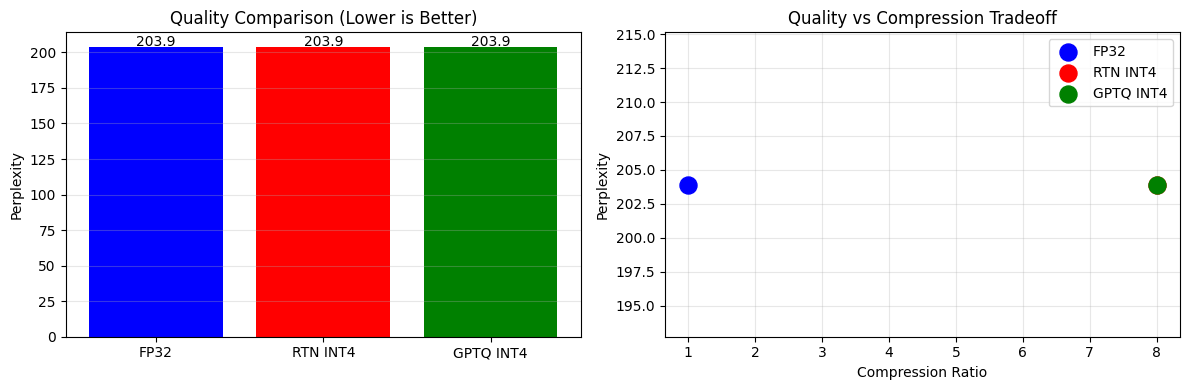

In [21]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = [r[0] for r in results]
ppls = [r[2] for r in results]
compressions = [r[3] for r in results]
colors = ['blue', 'red', 'green']

# Perplexity
ax = axes[0]
bars = ax.bar(methods, ppls, color=colors)
ax.set_ylabel('Perplexity')
ax.set_title('Quality Comparison (Lower is Better)')
ax.grid(True, alpha=0.3, axis='y')
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{ppl:.1f}', ha='center', fontsize=10)

# Perplexity vs Compression tradeoff
ax = axes[1]
for i, (name, bits, ppl, comp) in enumerate(results):
    ax.scatter(comp, ppl, s=150, c=colors[i], label=name, zorder=5)
ax.set_xlabel('Compression Ratio')
ax.set_ylabel('Perplexity')
ax.set_title('Quality vs Compression Tradeoff')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gptq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()